In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 20

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0430_dps_test.fits')

In [4]:
print(len(dps_df))

25767


In [5]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())

Data loading and processing took 7.32 seconds.


In [383]:
# example_idx = np.random.choice(len(DP_SPECTRA.targetID))
# example_df = dps_df.iloc[example_idx]
# example_id = 39627788428252634	
example_id = 39627806413424146	
example_df = dps_df[dps_df['TARGETID'] == example_id].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])

lam = desi_wavelength / (1 + example_df['Z'])
flux, ivar, mask = DP_SPECTRA.flux[example_idx], DP_SPECTRA.ivar[example_idx], DP_SPECTRA.mask[example_idx]
sigma = 1/np.sqrt(np.abs(ivar))
flux[mask] = np.nan

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_49488/865870474.py:10: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [384]:
example_df

TARGETID        39627806413424146
RA                     212.555206
DEC                      0.693839
Z                         0.18819
LOGM                     9.890221
                      ...        
BPT_2COMP_R                    16
BPT_2COMP                      32
LOGSFR_1COMP             1.199939
LOGSFR_2COMP             0.685285
dp_count                        3
Name: 20659, Length: 79, dtype: object

In [385]:
print(example_df['DV_R']-example_df['DV_L'])

76.97377


In [386]:
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

In [387]:
example_df[['OII3726_FLUX_1COMP', 'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP',
       'OIII4959_FLUX_1COMP', 'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP',]]

OII3726_FLUX_1COMP      29.420984
OII3729_FLUX_1COMP      39.159134
Hbeta_FLUX_1COMP        33.119362
OIII4959_FLUX_1COMP     44.810879
OIII5007_FLUX_1COMP    135.732025
NII6548_FLUX_1COMP      51.326374
Halpha_FLUX_1COMP       227.42363
NII6583_FLUX_1COMP     157.391983
Name: 20659, dtype: object

In [388]:
example_df[['OII3726_SNR', 'OII3729_SNR', 'Hbeta_SNR',
       'OIII4959_SNR', 'OIII5007_SNR', 'NII6548_SNR', 'Halpha_SNR',
       'NII6583_SNR',]]

OII3726_SNR      4.047674
OII3729_SNR      5.437277
Hbeta_SNR        3.733382
OIII4959_SNR     8.471797
OIII5007_SNR    25.541294
NII6548_SNR      8.327411
Halpha_SNR      36.965187
NII6583_SNR     25.265032
Name: 20659, dtype: object

In [389]:
example_df[['OII3726_DP', 'OII3729_DP', 'Hbeta_DP',
       'OIII4959_DP', 'OIII5007_DP', 'NII6548_DP', 'Halpha_DP',
       'NII6583_DP',]]

OII3726_DP     False
OII3729_DP     False
Hbeta_DP       False
OIII4959_DP    False
OIII5007_DP     True
NII6548_DP      True
Halpha_DP       True
NII6583_DP      True
Name: 20659, dtype: object

In [390]:
example_df['P_VALUE']

np.float32(0.00073589943)

In [391]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
# label_cols = ['[OII]3726', '[OII]3729', 'Hβ', '[OIII]4959', '[OIII]5007',
#               '[NII]6548', 'Hα', '[NII]6583', '[SII]6716', '[SII]6731']

label_cols = ['[OII]3726,3729', 'Hβ', '[OIII]5007',
              '[NII]6548,6583+Hα', '[SII]6716,6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

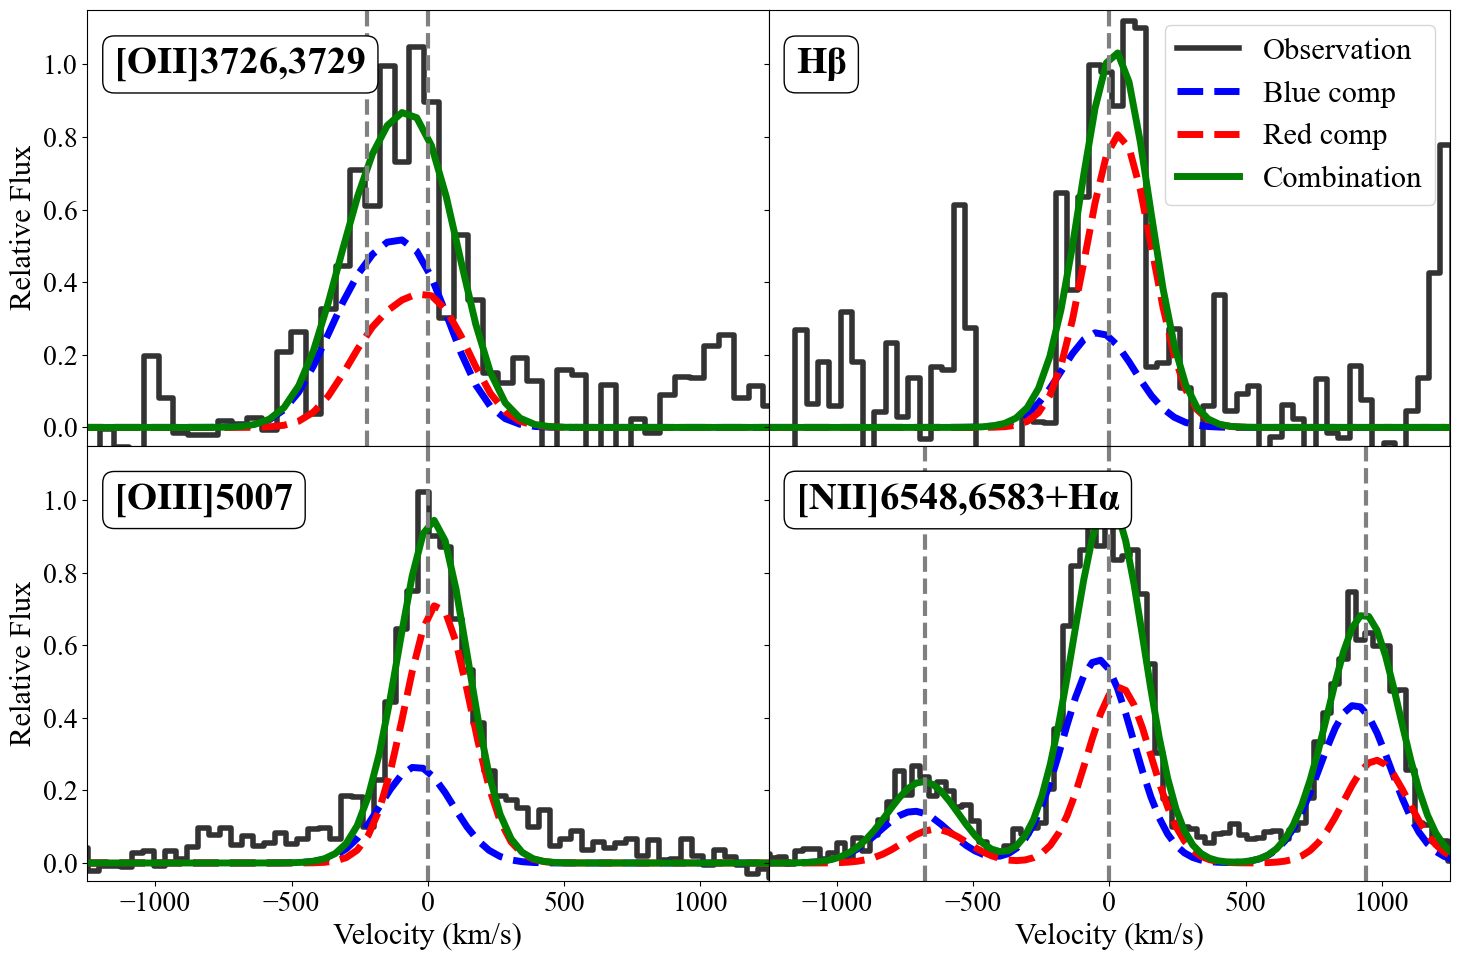

In [392]:
fig = plt.figure(figsize=(15, 10))

ranges = [
    (OII_rest[0]-15, OII_rest[1]+15),
    (Hbeta_rest[0]-15, Hbeta_rest[0]+15),
    # (OIII_rest[0]-15, OIII_rest[0]+15),
    (OIII_rest[1]-15, OIII_rest[1]+15),
    (NII_rest[0]-15, NII_rest[1]+15),
    # (SII_rest[0]-15, SII_rest[1]+15),
]
# Sort ranges by wavelength
ranges.sort(key=lambda x: x[0])

# Calculate the width of each range
widths = [r[1] - r[0] for r in ranges]

gs = fig.add_gridspec(2, 2, hspace=0.0, wspace=0.0)
axes = gs.subplots(sharex=True, sharey=True)


# Define lam_mask ranges based on the sorted plot ranges
lam_mask_ranges = [
    ((lam >= OII_rest[0]-40) & (lam <= OII_rest[0]-40+10)) | ((lam <= OII_rest[1]+40) & (lam >= OII_rest[1]+40-10)),
    ((lam >= Hbeta_rest[0]-40) & (lam <= Hbeta_rest[0]-40+10)) | ((lam <= Hbeta_rest[0]+40) & (lam >= Hbeta_rest[0]+40-10)),
    # ((lam >= OIII_rest[0]-40) & (lam <= OIII_rest[0]-40+10)) | ((lam <= OIII_rest[1]+40) & (lam >= OIII_rest[1]+40-10)),
    ((lam >= OIII_rest[0]-40) & (lam <= OIII_rest[0]-40+10)) | ((lam <= OIII_rest[1]+40) & (lam >= OIII_rest[1]+40-10)),
    ((lam >= NII_rest[0]-40) & (lam <= NII_rest[0]-40+10)) | ((lam <= NII_rest[1]+40) & (lam >= NII_rest[1]+40-10)),
    # ((lam >= SII_rest[0]-40) & (lam <= SII_rest[0]-40+10)) | ((lam <= SII_rest[1]+40) & (lam >= SII_rest[1]+40-10)),
]

lam0 = [
    OII_rest[1],
    Hbeta_rest[0],
    OIII_rest[1],
    Halpha_rest[0],
    # SII_rest[0],
]
# Sort lam_mask_ranges to match sorted plot ranges
lam_mask_ranges.sort(key=lambda x: lam[x].mean() if np.any(x) else 0)

axes = axes.flatten()
for i, ax in enumerate(axes):
    x0, x1 = ranges[i]
    # ax.set_xlim(x0, x1)
    ax.set_xlim(-1250, 1250)
    ax.set_ylim(bottom=-0.05, top=1.15)
    lam_mask = lam_mask_ranges[i]

    v_max = np.nanmax(flux[(lam > x0) & (lam < x1)])
    # v_max = np.nanmax(flux)
    if v_max == 0 or np.isnan(v_max): v_max = 1.0
    
    conti_adj = np.nanmedian(flux[lam_mask]) if np.any(flux[lam_mask]) else 0

    ax.plot(lam2vel(lam, lam0[i]), (flux-conti_adj)/v_max, color='k', linewidth=4, label='Observation', drawstyle='steps-mid', alpha=0.8)
    ax.plot(lam2vel(lam, lam0[i]), (test_2comp_l)/v_max, linestyle='--', linewidth=5, color='blue', label='Blue comp')
    ax.plot(lam2vel(lam, lam0[i]), (test_2comp_r)/v_max, linestyle='--', linewidth=5, color='red', label='Red comp')
    ax.plot(lam2vel(lam, lam0[i]), (test_2comp)/v_max, linewidth=5, color='green', label='Combination')

    line_label = f'{label_cols[i]}'

    ax.text(-1150, 1., line_label, color='k', fontsize=28, weight='bold', ha='left', va='center', bbox=dict(boxstyle='round,pad=0.3', edgecolor='k', facecolor='white'))

    
    
    for j, line in enumerate(lam0):
        if x0 < line < x1:
            ax.axvline(x=0, color='gray', linestyle='--', linewidth=3)
            if i == 0:
                ax.axvline(x=lam2vel(OII_rest[0], lam0[i]), color='gray', linestyle='--', linewidth=3)
            elif i == 3:
                ax.axvline(x=lam2vel(NII_rest[0], lam0[i]), color='gray', linestyle='--', linewidth=3)
                ax.axvline(x=lam2vel(NII_rest[1], lam0[i]), color='gray', linestyle='--', linewidth=3)



axes[1].legend(fontsize=22, loc='upper right', frameon=True)
# axes[2].legend(fontsize=22, loc='right', frameon=True)
axes[0].set_ylabel(r'Relative Flux', fontsize=22)
axes[-2].set_ylabel(r'Relative Flux', fontsize=22)
axes[-2].set_xlabel(r'Velocity (km/s)', fontsize=22, y=0.1)
axes[-1].set_xlabel(r'Velocity (km/s)', fontsize=22, y=0.1)
plt.tight_layout(rect=[0., 0, 1, 1])
# plt.savefig('./figures/asroc/example_spectrum.pdf', transparent='True', bbox_inches='tight')
plt.show()


In [393]:
print(image_link(example_df['RA'], example_df['DEC'], plot=False, save_image=False, fname=f"./figures/asroc/example_image.jpg", side_arcmin=0.33))
print(spectrum_link(example_df['TARGETID']))

https://www.legacysurvey.org/viewer?ra=212.55520629882812&dec=0.6938385367393494&layer=hsc-dr3&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627806413424146
